### Generaione dei dati

In [458]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import statistics
import math

In [459]:
def gaussian_pdf(x, mu, sigma):
    return (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-((x - mu) ** 2) / (2 * sigma ** 2))

In [460]:
def plot_histo_gauss_mult(titolo, dati, mu, sigma, bins=80):
    fig, axes = plt.subplots(1, 2, figsize=(10,5))

    colors= ['orange', 'blue']
    datasets = dati
    titles = ['n1', 'n2']
    mu = mu
    sigma= sigma

    for ax, data, t, mu, sigma, colors in zip(axes, datasets, titles, mu, sigma, colors):
        # calcolo istogramma senza disegnare subito
        h, bin_edges = np.histogram(data, bins=bins, range= (mu-4*sigma, mu+4*sigma))
        delta_x = bin_edges[1] - bin_edges[0]
        centri = (bin_edges[:-1] + bin_edges[1:]) / 2

        # disegno istogramma
        ax.bar(centri, h, width=delta_x, color= colors,  alpha=0.6, label='Dati')

        # barre di errore Poisson
        ax.errorbar(centri, h, yerr=np.sqrt(h), xerr=delta_x/2,
                    fmt='none', color='grey', lw=1, label='Errore Standard')

        # curva normale standard (PDF moltiplicata per n*Δx)
        ax.plot(centri, gaussian_pdf(centri, mu, sigma)*len(data)*delta_x,
                color='red', label='Normale standard')
        ax.set_title(t)
        ax.set_xlabel('x')
        ax.set_ylabel('Conteggi')
        ax.legend(fontsize=8)

    fig.suptitle(titolo)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

In [461]:
def covarianza(x, y, mu, c):
    n = len(x)
    cov = sum((x[i] - mu[0]) * (y[i] - mu[1]) for i in range(n)) / c
    return cov

In [462]:
def correllazione(X, Y, mu, c):
        var1 = covarianza(X, X, mu, c)
        var2 = covarianza(Y, Y, mu, c)
        return covarianza(X, Y, mu, c) / np.sqrt((var1 * var2))

In [463]:
def Q2(x, y, mu, sigma, r):
    return 1/(1-r)*(((x - mu[0])**2 / sigma[0]**2) + ((y - mu[1])**2 / sigma[1]**2) - (2*r*(x - mu[0])*(y - mu[1])/(sigma[0]*sigma[1])))

In [464]:
def varianza_correllate(X, Y, mu, c):
    mu_x= [mu[0],mu[0]]
    mu_y= [mu[1],mu[1]]
    var = covarianza(X, X, mu_x, c) + covarianza(Y, Y, mu_y, c) - 2 * covarianza(X, Y, mu, c)
    var = np.sqrt(var)
    return var

In [465]:
N=10000
n= [np.random.normal(10,0.2,N), np.random.normal(20,0.2,N)]
mu = [10, 20]
sigma = [0.2, 0.2]


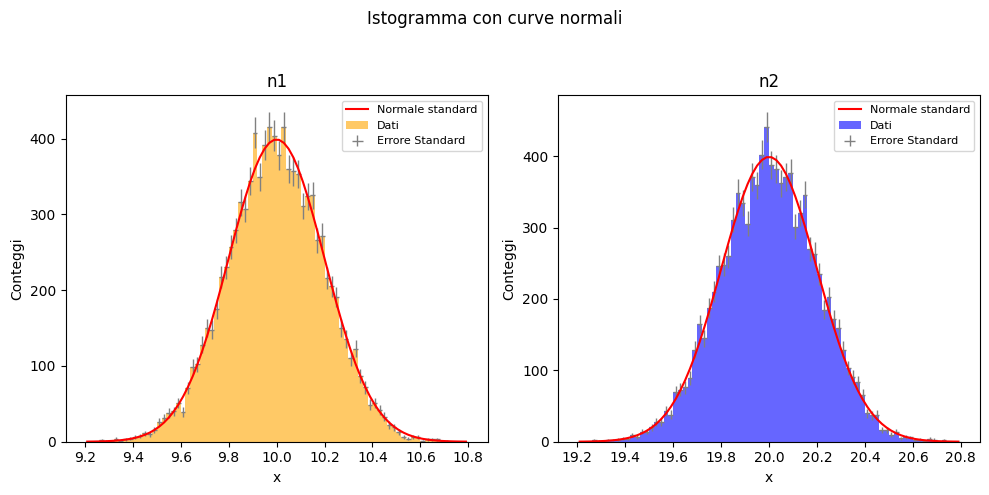

In [466]:
plot_histo_gauss_mult('Istogramma con curve normali', n, [10, 20], [0.2, 0.2], bins=80)


In [467]:
cov = covarianza(n[0], n[1], mu, N-1)
print(f"Covarianza con Bessel: {cov}")
cov = covarianza(n[0], n[1], mu, N)
print(f"Covarianza baised: {cov}")

cor = correllazione(n[0], n[1], mu, N-1)
print(f"Correlazione: {cor}")
cor = correllazione(n[0], n[1], mu, N)
print(f"Correlazione baised: {cor}")

var_n1 = covarianza(n[0], n[0], [mu[0], mu[0]], N-1)
print(f"Varianza di n1 con Bessel: {var_n1}")
var_s1 = covarianza(n[0], n[0], [mu[0], mu[0]], N)
print(f"Varianza di n1 baised: {var_s1}")

var_n2 = covarianza(n[1], n[1], [mu[1], mu[1]], N-1)
print(f"Varianza di n2 con Bessel: {var_n2}")
var_s2 = covarianza(n[1], n[1], [mu[1], mu[1]], N)
print(f"Varianza di n2 baised: {var_s2}")


Covarianza con Bessel: 0.00020012478966952924
Covarianza baised: 0.00020010477719056228
Correlazione: 0.0033006728919072145
Correlazione baised: 0.003300672891907214
Varianza di n1 con Bessel: 0.040306582203661116
Varianza di n1 baised: 0.04030255154544075
Varianza di n2 con Bessel: 0.040332487599368555
Varianza di n2 baised: 0.04032845435060862


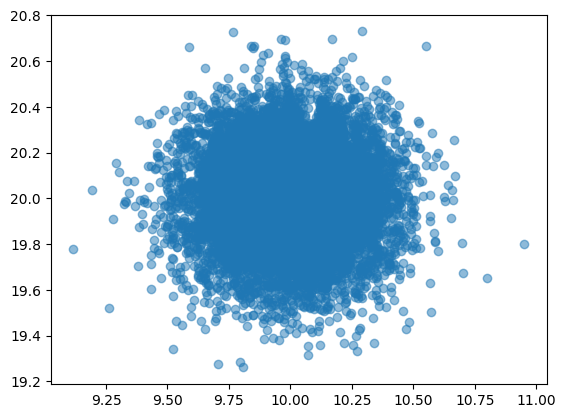

In [468]:
plt.scatter(n[0], n[1], alpha=0.5)

Numero di punti dentro l'ellisse: 3894


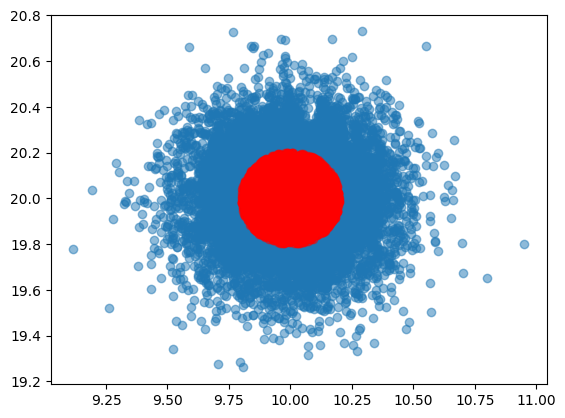

Rapporto fra punti e coppie: 0.3894


In [469]:
Q = Q2(n[0], n[1], mu, sigma, 0)
punti_ellisse = np.where(Q <= 1)
print(f"Numero di punti dentro l'ellisse: {len(punti_ellisse[0])}")
plt.scatter(n[0], n[1], alpha=0.5)
plt.scatter(n[0][punti_ellisse], n[1][punti_ellisse], color='red', alpha=0.5, label='Punti dentro l\'ellisse')
plt.show()
print(f"Rapporto fra punti e coppie: {len(punti_ellisse[0])/N}")

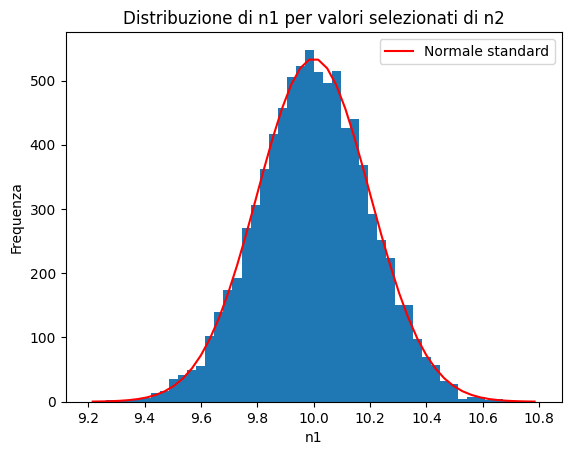

In [470]:
punti_selezionati= np.where((n[1] >= 19.2) & (n[1] <= 20.2))

h1, bins1, patches = plt.hist(n[0][punti_selezionati], bins=50, range=(10-4*0.2, 10+4*0.2))
centri1 = (bins1[:-1] + bins1[1:]) / 2
delta_x1 = bins1[1] - bins1[0]
plt.plot(centri1, gaussian_pdf(centri1, 10, 0.2)*len(n[0][punti_selezionati])*delta_x1, color='red', label='Normale standard')
plt.xlabel('n1')
plt.ylabel('Frequenza')
plt.title('Distribuzione di n1 per valori selezionati di n2')
plt.legend()
plt.show()

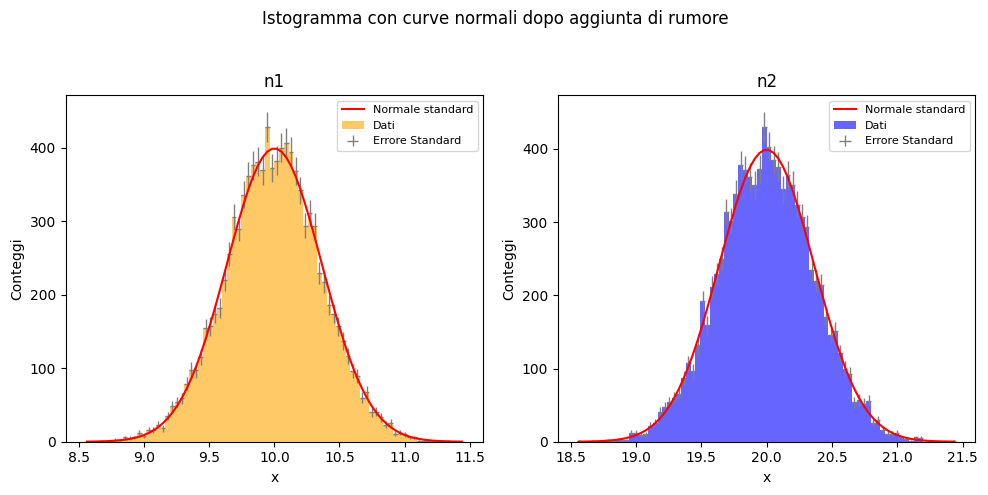

In [471]:
s=np.random.normal(0,0.3,N)
n[0]=n[0]+s
n[1]=n[1]+s

var_s = [(covarianza(n[0], n[0], [mu[0], mu[0]], N-1)), (covarianza(n[1], n[1], [mu[1], mu[1]], N-1))]
sigma_s = [np.sqrt(covarianza(n[0], n[0], [mu[0], mu[0]], N-1)), np.sqrt(covarianza(n[1], n[1], [mu[1], mu[1]], N-1))]

plot_histo_gauss_mult('Istogramma con curve normali dopo aggiunta di rumore', n, mu, sigma_s, bins=80)

In [472]:
var_n1 = covarianza(n[0], n[0], [mu[0], mu[0]], N-1)
print(f"Varianza di n1 con Bessel: {var_n1}")
var_n1 = covarianza(n[0], n[0], [mu[0], mu[0]], N)
print(f"Varianza di n1 baised: {var_n1}") 

var_n2 = covarianza(n[1], n[1], [mu[1], mu[1]], N-1)
print(f"Varianza di n2 con Bessel: {var_n2}")  
var_n2 = covarianza(n[1], n[1], [mu[1], mu[1]], N)
print(f"Varianza di n2 baised: {var_n2}")

corr = correllazione(n[0], n[1], mu, N-1) 
print(f"Correlazione: {corr}")

val_s1=print(f"Valore atteso varianza 1: {var_s1+0.3**2}")
val_s2=print(f"Valore atteso varianza 2: {var_s2+0.3**2}")

Varianza di n1 con Bessel: 0.13271586492713594
Varianza di n1 baised: 0.13270259334064324
Varianza di n2 con Bessel: 0.13177024972803333
Varianza di n2 baised: 0.13175707270306056
Correlazione: 0.6477721050028931
Valore atteso varianza 1: 0.13030255154544074
Valore atteso varianza 2: 0.1303284543506086


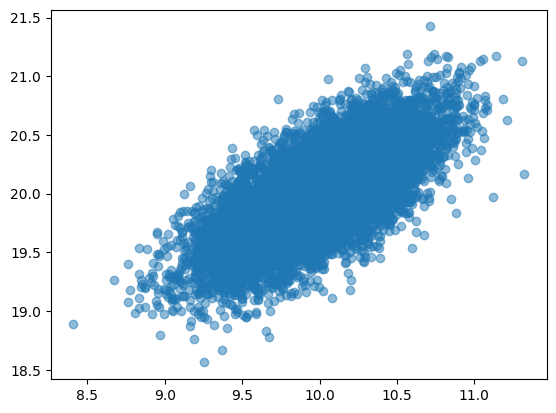

In [473]:
plt.scatter(n[0], n[1], alpha=0.5)

Numero di punti dentro l'ellisse: 2791


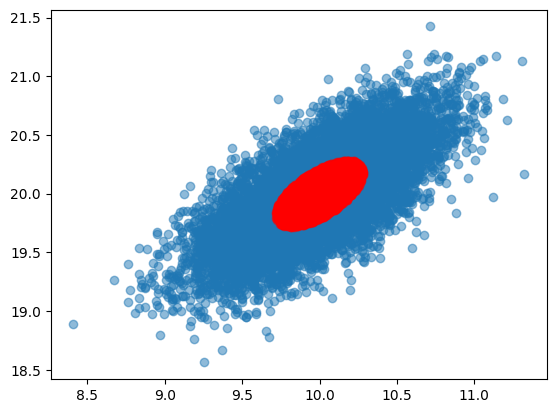

Rapporto fra punti e coppie: 0.2791


In [474]:
Q = Q2(n[0], n[1],  mu, sigma_s, corr)
punti_ellisse = np.where(Q <= 1)
plt.scatter(n[0][punti_ellisse], n[1][punti_ellisse], color='red', alpha=0.5, label='Punti dentro l\'ellisse')
print(f"Numero di punti dentro l'ellisse: {len(punti_ellisse[0])}")
plt.scatter(n[0], n[1], alpha=0.5)
plt.scatter(n[0][punti_ellisse], n[1][punti_ellisse], color='red', alpha=0.5, label='Punti dentro l\'ellisse')
plt.show()
print(f"Rapporto fra punti e coppie: {len(punti_ellisse[0])/N}")

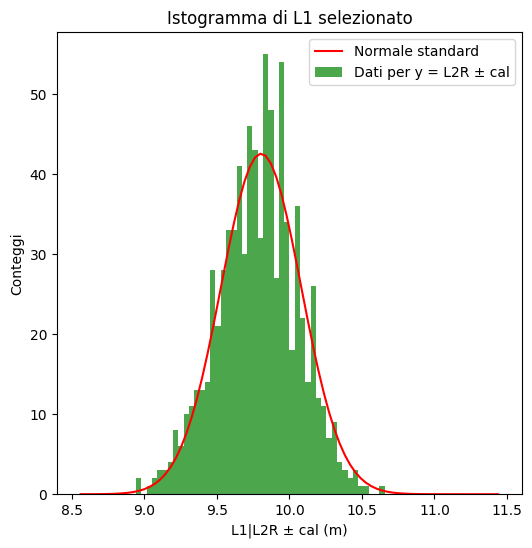

In [475]:
tolleranza = 0.05

lista_2 = np.where(np.abs(n[1] - 19.7) < tolleranza)
n1_selected1= n[0][lista_2]

h1, bin_edges1 = np.histogram(n1_selected1, bins=80, range= (mu[0]-4*sigma_s[0], mu[0]+4*sigma_s[0]))
delta_x1 = bin_edges1[1] - bin_edges1[0] 
centri1 = (bin_edges1[:-1] + bin_edges1[1:]) / 2



plt.figure(figsize=(6,6))
plt.bar(centri1, h1, width=delta_x1, color='green', alpha=0.7, label='Dati per y = L2R ± cal')
plt.plot(centri1, gaussian_pdf(centri1, mu[0] + corr* sigma_s[0]/sigma_s[1]*(19.7-mu[1]), sigma_s[0]*np.sqrt(1- corr**2))*len(n1_selected1)*delta_x1, color='red', label='Normale standard')
plt.xlabel('L1|L2R ± cal (m)')
plt.ylabel('Conteggi')
plt.title('Istogramma di L1 selezionato')
plt.legend()
plt.show()
